## 1. Importing Libs

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt


## 2. Data Loading

In [2]:
titanic = pd.read_csv('titanic_clean.csv')

## 3. Data Preprocessing

In [3]:
X = titanic.drop('Survived', axis=1)
y = titanic['Survived']

X = X.astype(float)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(X_train)
x_test_scaled = scaler.transform(X_test) 

X_train = torch.tensor(x_train_scaled, dtype=torch.float32)
X_test = torch.tensor(x_test_scaled, dtype=torch.float32)

y_train = torch.tensor(y_train.values, dtype=torch.float32).reshape(-1,1)
y_test = torch.tensor(y_test.values, dtype=torch.float32).reshape(-1,1)


## 4. NN Model

In [4]:
torch.manual_seed(42)

model = nn.Sequential(
    nn.Linear(16, 8),
    nn.ReLU(),
    nn.Dropout(p = 0.3),
    nn.Linear(8, 8),
    nn.ReLU(),
    nn.Dropout(p = 0.3),
    nn.Linear(8, 1),
    nn.Sigmoid()
)

print(model)

criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 0.001)

Sequential(
  (0): Linear(in_features=16, out_features=8, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.3, inplace=False)
  (3): Linear(in_features=8, out_features=8, bias=True)
  (4): ReLU()
  (5): Dropout(p=0.3, inplace=False)
  (6): Linear(in_features=8, out_features=1, bias=True)
  (7): Sigmoid()
)


## 5. Training Loop

In [5]:
losses = []

for epoch in range(500):
    model.train()
    y_pred = model(X_train)
    loss = criterion(y_pred, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())
    if epoch % 100 == 0:
        print(f'Epoch {epoch} | Loss: {loss.item():.4f}')

Epoch 0 | Loss: 0.7169
Epoch 100 | Loss: 0.6511
Epoch 200 | Loss: 0.5117
Epoch 300 | Loss: 0.4637
Epoch 400 | Loss: 0.4651


## 6. Model Evaluation

In [6]:
model.eval()
with torch.no_grad():
    y_pred_test = model(X_test)
    predicted = (y_pred_test >= 0.5).float()  
    accuracy = (predicted == y_test).float().mean()
    print(f'Accuracy: {accuracy:.4f}')

Accuracy: 0.8258


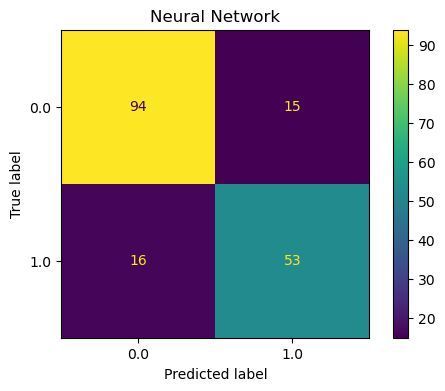

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test.numpy(),
    predicted.numpy(),
    ax=ax
)
ax.set_title('Neural Network')
plt.show()

## 7. Visualization

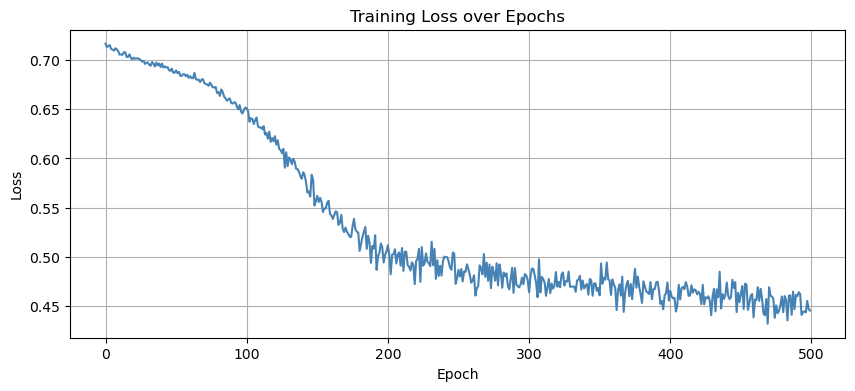

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(losses, color='steelblue')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss over Epochs')
plt.grid(True)
plt.show()